In [44]:
import numpy as np
from pymoo.core.problem import Problem

class Schaffer(Problem):

    def __init__(self):
        super().__init__(
            n_var=1,
            n_obj=2,
            n_constr=0,
            xl=-10,
            xu=10
        )

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[:, 0] ** 2
        f2 = (x[:, 0] - 2) ** 2
        out["F"] = np.column_stack([f1, f2])

In [45]:
from pymoo.algorithms.moo.nsga2 import NSGA2


problem = Schaffer()

from pymoo.optimize import minimize

res = minimize(
    problem,
    NSGA2(pop_size=100),
    termination=("n_gen", 100)
)

# -------------------
# PRINT RESULTS
# -------------------

print("Best solutions (X):")
print(res.X)

print("\nObjective values (F):")
print(res.F)

Best solutions (X):
[[2.04592300e-04]
 [1.99996141e+00]
 [1.58595522e+00]
 [1.53909268e+00]
 [1.24179950e+00]
 [1.19657475e+00]
 [1.29624360e-01]
 [1.84143862e+00]
 [1.31467025e+00]
 [1.76776297e+00]
 [2.53095650e-01]
 [8.05457583e-01]
 [4.86647291e-01]
 [2.88685712e-01]
 [6.38629536e-01]
 [1.09254049e+00]
 [7.71022893e-01]
 [1.48194598e-01]
 [1.80189641e+00]
 [6.70052517e-01]
 [3.94802931e-02]
 [7.42668152e-01]
 [1.49802973e+00]
 [6.02247071e-01]
 [4.71047677e-01]
 [4.49615702e-01]
 [1.29291997e+00]
 [1.27817897e+00]
 [1.33977331e+00]
 [1.69918469e-01]
 [3.99391788e-01]
 [1.04037024e+00]
 [3.20461371e-01]
 [4.31570364e-01]
 [1.86446943e+00]
 [8.62303694e-01]
 [1.80118082e+00]
 [8.16367792e-02]
 [9.71885674e-01]
 [1.51509952e+00]
 [9.92471145e-01]
 [1.61652407e+00]
 [1.92890859e+00]
 [2.26502323e-01]
 [1.02971492e+00]
 [9.98674555e-02]
 [9.40813578e-01]
 [9.14599728e-01]
 [1.38023097e+00]
 [1.88321108e+00]
 [1.06486960e+00]
 [5.14752365e-01]
 [1.25731311e+00]
 [7.64999237e-01]
 [1.6532

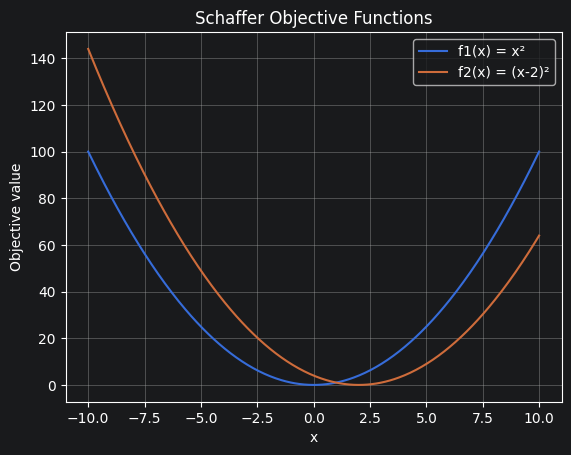

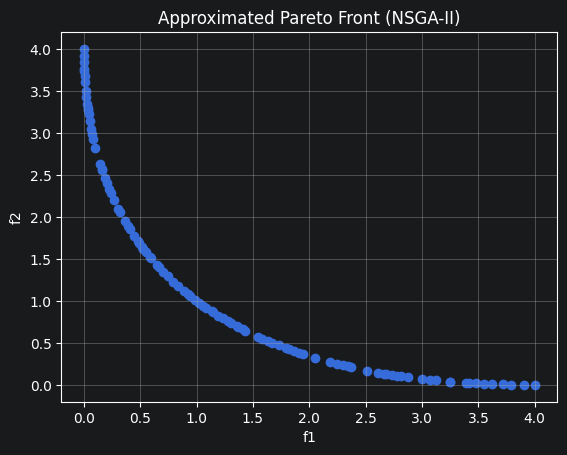

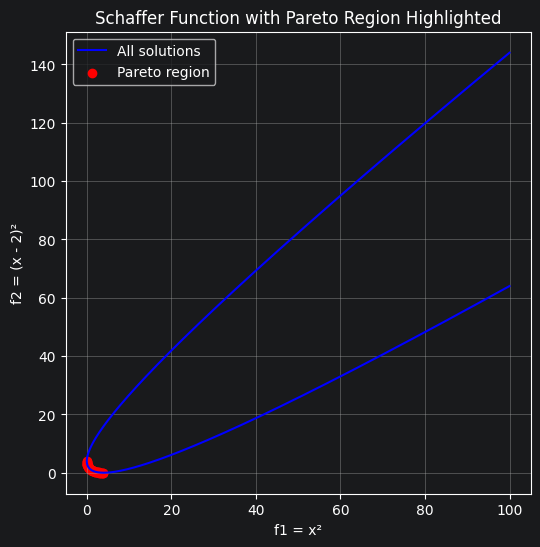

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the objective functions
x = np.linspace(-10, 10, 400)

f1 = x**2
f2 = (x - 2)**2

plt.figure()
plt.plot(x, f1, label="f1(x) = x²")
plt.plot(x, f2, label="f2(x) = (x-2)²")
plt.xlabel("x")
plt.ylabel("Objective value")
plt.title("Schaffer Objective Functions")
plt.legend()
plt.grid()

# Plot the Pareto front found by NSGA-II
plt.figure()
plt.scatter(res.F[:, 0], res.F[:, 1])
plt.xlabel("f1")
plt.ylabel("f2")
plt.title("Approximated Pareto Front (NSGA-II)")
plt.grid()

plt.show()



x = np.linspace(-10, 10, 400)

f1 = x**2
f2 = (x - 2)**2

pareto_mask = (x >= 0) & (x <= 2)

plt.figure(figsize=(6, 6))

# full curve (non-Pareto + Pareto together)
plt.plot(f1, f2, color="blue", label="All solutions")

# highlight Pareto part
plt.scatter(f1[pareto_mask], f2[pareto_mask], color="red", label="Pareto region")

plt.xlabel("f1 = x²")
plt.ylabel("f2 = (x - 2)²")
plt.title("Schaffer Function with Pareto Region Highlighted")
plt.grid()
plt.legend()
plt.show()

In [35]:
from pymoo.problems import get_problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt

# problem
problem = get_problem("tnk")

# algorithm
algorithm = NSGA2(pop_size=100)

# optimization
res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 100),
    seed=1,
    verbose=True
)

# -------------------
# results
# -------------------
print("Decision variables (X):")
print(res.X)

print("\nObjective values (F):")
print(res.F)

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      igd      |       gd      |       hv     
     1 |      100 |      1 |  0.000000E+00 |  6.9626081652 |  0.4334523082 |  0.0696937788 |  0.0861364192
     2 |      200 |      7 |  0.000000E+00 |  1.4452084117 |  0.2327841093 |  0.1492538418 |  0.1005182961
     3 |      300 |      9 |  0.000000E+00 |  0.2000368085 |  0.0731603258 |  0.0661383752 |  0.2032353430
     4 |      400 |     11 |  0.000000E+00 |  0.0049004344 |  0.0579561523 |  0.0423350407 |  0.2390941652
     5 |      500 |     10 |  0.000000E+00 |  0.000000E+00 |  0.0543811610 |  0.0321355590 |  0.2521648295
     6 |      600 |     13 |  0.000000E+00 |  0.000000E+00 |  0.0477927710 |  0.0273075731 |  0.2601834261
     7 |      700 |     17 |  0.000000E+00 |  0.000000E+00 |  0.0458931853 |  0.0283609141 |  0.2643422042
     8 |      800 |     18 |  0.000000E+00 |  0.000000E+00 |  0.0456764441 |  0.0261636319 |  0.2704805599
     9 |      900 |     20 |  0.00000

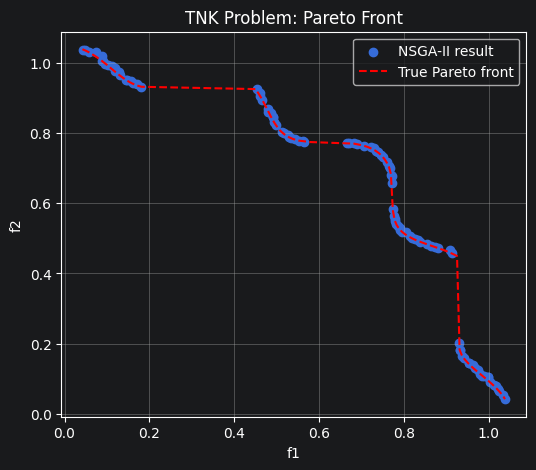

In [34]:
plt.figure(figsize=(6, 5))

# NSGA-II result (approximation)
plt.scatter(res.F[:, 0], res.F[:, 1], label="NSGA-II result")

# true Pareto front
pf = problem.pareto_front()
plt.plot(pf[:, 0], pf[:, 1], 'r--', label="True Pareto front")

plt.xlabel("f1")
plt.ylabel("f2")
plt.title("TNK Problem: Pareto Front")
plt.legend()
plt.grid()
plt.show()

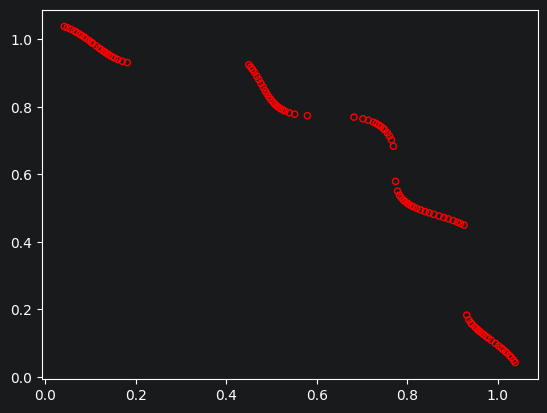

In [28]:
from pymoo.problems import get_problem
from pymoo.visualization.util import plot

problem = get_problem("tnk")
plot(problem.pareto_front(), no_fill=True)